# Thesis Analysis: Comparative Prompt Engineering for Student Assessment

This notebook implements a comparative analysis of different LLM prompting strategies (Zero-shot, Few-shot, etc.) to assess student code submissions.

It reuses existing data pipelines from the project while introducing a controlled environment to test different prompt types.

In [11]:
# 1. Imports and API Configuration
import json
import time
import ast
import random
import importlib

import pandas as pd
from google import genai
from google.genai import types

# Reload refactored modules to pick up changes without kernel restart
import utils.constants, utils.dataset
import lib.prompts, lib.normalizer, lib.prediction_validator, lib.llm_batch_analyzer
for mod in [utils.constants, utils.dataset, lib.normalizer, lib.prompts,
            lib.llm_batch_analyzer, lib.prediction_validator]:
    importlib.reload(mod)

from utils.constants import (
    GEMINI_API_KEY,
    FOCUS_PROBLEMS,
    VALIDATION_PROBLEMS,
    EARLY_STRUGGLE_THRESHOLD,
    FUTURE_STRUGGLE_THRESHOLD,
)
from utils.dataset import (
    load_topics_json,
    load_problem_descriptions,
    load_joined_datasets,
    get_best_attempts,
)
from lib.llm_batch_analyzer import format_submissions, clean_json_response
from lib.prompts import SIMPLE_STRATEGIES, build_curriculum_aware_prompt
from lib.normalizer import normalize_gap_tag, normalize_predictions
from lib.prediction_validator import (
    validate_predictions,
    load_problem_topics,
    compute_metrics_by_strategy,
)

client = genai.Client(api_key=GEMINI_API_KEY)

print("Libraries imported and client initialized.")

Libraries imported and client initialized.


In [14]:
# 2. Data Loading and Mixed-Sample Construction

# Target: 30 total, 50/50 split (auto-balances to smaller pool)
TARGET_TOTAL = 30

print("Loading datasets...")
df = load_joined_datasets()

if df is not None:
    best_df = get_best_attempts(df)

    # Identify student groups based on early performance
    focus_attempts = best_df[best_df["ProblemID"].isin(FOCUS_PROBLEMS)]

    # Group A: Struggling (low early + low future)
    struggling_early_ids = set(
        focus_attempts[focus_attempts["Score"] < EARLY_STRUGGLE_THRESHOLD]["SubjectID"]
    )
    future_attempts = best_df[best_df["ProblemID"].isin(VALIDATION_PROBLEMS)]
    future_avgs = future_attempts.groupby("SubjectID")["Score"].mean()
    struggling_future_ids = set(future_avgs[future_avgs < FUTURE_STRUGGLE_THRESHOLD].index)
    persistent_struggling = list(struggling_early_ids & struggling_future_ids)

    # Group B: Non-struggling (high early + high future)
    non_struggling_early_ids = set(
        focus_attempts[focus_attempts["Score"] >= EARLY_STRUGGLE_THRESHOLD]["SubjectID"]
    )
    non_struggling_future_ids = set(future_avgs[future_avgs >= FUTURE_STRUGGLE_THRESHOLD].index)
    confirmed_non_struggling = list(non_struggling_early_ids & non_struggling_future_ids)

    print(f"\n--- Pool Sizes ---")
    print(f"Persistent strugglers available: {len(persistent_struggling)}")
    print(f"Confirmed non-struggling available: {len(confirmed_non_struggling)}")

    # Auto-balance: equal from each group, capped at half the target
    half = TARGET_TOTAL // 2
    n_per_group = min(half, len(persistent_struggling), len(confirmed_non_struggling))

    random.seed(42)
    sampled_struggling = random.sample(persistent_struggling, n_per_group)
    sampled_non_struggling = random.sample(confirmed_non_struggling, n_per_group)
    all_sampled_ids = sampled_struggling + sampled_non_struggling

    # Ground truth: student_id -> bool (True = actually struggles)
    ground_truth_labels = {sid: True for sid in sampled_struggling}
    ground_truth_labels.update({sid: False for sid in sampled_non_struggling})

    print(f"\n--- Final Sample (50/50 balanced) ---")
    print(f"Struggling: {len(sampled_struggling)}")
    print(f"Non-struggling: {len(sampled_non_struggling)}")
    print(f"Total: {len(all_sampled_ids)}")

    # Build submission list: one submission per student from focus problems
    candidate_df = best_df[
        (best_df["SubjectID"].isin(all_sampled_ids))
        & (best_df["ProblemID"].isin(FOCUS_PROBLEMS))
    ]
    test_submissions = (
        candidate_df.sample(frac=1, random_state=42)
        .drop_duplicates(subset=["SubjectID"])
        .to_dict("records")
    )
    for sub in test_submissions:
        sub["ground_truth_struggling"] = ground_truth_labels.get(sub["SubjectID"])

    print(f"\nDataset ready: {len(test_submissions)} submissions")
    struggling_count = sum(1 for s in test_submissions if s["ground_truth_struggling"])
    non_struggling_count = len(test_submissions) - struggling_count
    print(f"  Struggling: {struggling_count} | Non-struggling: {non_struggling_count}")

    # Verify one example from each group
    for s in test_submissions[:2]:
        lbl = "STRUGGLING" if s["ground_truth_struggling"] else "NON-STRUGGLING"
        future_perf = best_df[
            (best_df["SubjectID"] == s["SubjectID"])
            & (best_df["ProblemID"].isin(VALIDATION_PROBLEMS))
        ]
        avg_f = future_perf["Score"].mean() if not future_perf.empty else 0
        print(f"  Example: Student {s['SubjectID']} [{lbl}]  Future Avg: {avg_f:.2f}")
else:
    print("Error: Could not load datasets.")

Loading datasets...
Main table: 201,570 rows
CodeState table: 69,627 rows
Subject table: 381 rows
Joined dataset: 191,584 rows
Best attempts: 15,375 rows (372 students, 50 problems)

--- Pool Sizes ---
Persistent strugglers available: 12
Confirmed non-struggling available: 300

--- Final Sample (50/50 balanced) ---
Struggling: 12
Non-struggling: 12
Total: 24

Dataset ready: 24 submissions
  Struggling: 12 | Non-struggling: 12
  Example: Student 9948 [STRUGGLING]  Future Avg: 0.61
  Example: Student 10155 [STRUGGLING]  Future Avg: 0.52


In [15]:
# 3. Build Prompt Strategy Registry

# Load curriculum data for the Curriculum-Aware prompt
topics = load_topics_json()
problems = load_problem_descriptions()

def get_final_version_prompt() -> str:
    """Curriculum-Aware prompt with strict KC tags."""
    base = build_curriculum_aware_prompt(topics or {}, problems, FOCUS_PROBLEMS)
    return base

# Full strategy registry
PROMPT_STRATEGIES = {
    **{name: fn for name, fn in SIMPLE_STRATEGIES.items()},
    "Final-Curriculum-Aware": get_final_version_prompt,
}

print(f"Prompt strategies defined: {list(PROMPT_STRATEGIES.keys())}")

Prompt strategies defined: ['Zero-Shot', 'Few-Shot', 'Chain-of-Thought', 'Final-Curriculum-Aware']


In [16]:
# 4. Analysis Engine

ACTIVE_PROMPTS = list(PROMPT_STRATEGIES.keys())

def run_single_analysis(submission: dict, system_instr: str) -> dict:
    """Run analysis for a single submission using a specific prompt strategy."""
    formatted_input = format_submissions([submission])
    try:
        response = client.models.generate_content(
            model="gemini-2.5-flash",
            contents=formatted_input,
            config=types.GenerateContentConfig(
                system_instruction=system_instr,
                temperature=0.3,
                response_mime_type="application/json",
            ),
        )
        if response.text:
            return {"status": "success", "data": json.loads(clean_json_response(response.text))}
    except Exception as e:
        return {"status": "error", "error_msg": str(e)}
    return {"status": "no_response"}

print(f"Engine configured. Active prompts: {ACTIVE_PROMPTS}")

Engine configured. Active prompts: ['Zero-Shot', 'Few-Shot', 'Chain-of-Thought', 'Final-Curriculum-Aware']


In [17]:
# 5. Execution: Run Comparative Analysis

results_data = []

print(f"Starting comparison: {len(test_submissions)} students x {len(ACTIVE_PROMPTS)} strategies...\n")

for index, sub in enumerate(test_submissions):
    student_id = sub["SubjectID"]
    problem_id = sub["ProblemID"]
    compile_result = sub.get("Compile.Result", "Unknown")
    gt_label = sub.get("ground_truth_struggling")
    gt_str = "STRUGGLING" if gt_label else "NON-STRUGGLING"

    print(f"--- [{index+1}/{len(test_submissions)}] Student {student_id} (Problem {problem_id}) [{gt_str}] ---")

    for strategy in ACTIVE_PROMPTS:
        if strategy not in PROMPT_STRATEGIES:
            continue

        print(f"  > {strategy}...", end=" ")
        system_instruction = PROMPT_STRATEGIES[strategy]()

        start_time = time.time()
        result = run_single_analysis(sub, system_instruction)
        duration = time.time() - start_time

        if result["status"] == "success":
            raw_data = result["data"]
            gaps = []
            predictions = []

            if strategy == "Final-Curriculum-Aware":
                # Curriculum-Aware wraps output in student_analysis list
                if "student_analysis" in raw_data and isinstance(raw_data["student_analysis"], list):
                    entry = raw_data["student_analysis"][0]
                    for g in entry.get("knowledge_gaps", []):
                        gaps.append(g.get("category") or g.get("gap") or g.get("missing_concept") or "Unknown")
                    for p in entry.get("future_predictions", []):
                        predictions.append(p.get("topic_tag") or p.get("at_risk_topic") or "Unknown")
            else:
                # Zero-Shot / Few-Shot / Chain-of-Thought
                raw_gaps = raw_data.get("knowledge_gaps", [])
                gaps = [g.get("gap", str(g)) if isinstance(g, dict) else g for g in raw_gaps]
                raw_preds = raw_data.get("future_predictions", [])
                predictions = [p.get("at_risk_topic", str(p)) if isinstance(p, dict) else p for p in raw_preds]

            # Normalize to canonical tags
            normalized_gaps = [normalize_gap_tag(g) for g in gaps]
            normalized_preds = [normalize_gap_tag(p) for p in predictions]

            results_data.append({
                "Student_ID": student_id,
                "Problem_ID": problem_id,
                "Compile_Status": compile_result,
                "Prompt_Strategy": strategy,
                "Ground_Truth_Struggling": gt_label,
                "Identified_Gaps": str(gaps),
                "Normalized_Gaps": str(normalized_gaps),
                "Predictions": str(predictions),
                "Normalized_Predictions": str(normalized_preds),
                "Execution_Time_Sec": round(duration, 2),
                "Raw_JSON": json.dumps(raw_data),
            })
            print(f"done ({duration:.1f}s). Gaps: {normalized_gaps}, Preds: {normalized_preds}")
        else:
            print(f"ERROR: {result.get('error_msg', 'no response')}")

print(f"\nAnalysis complete. {len(results_data)} total results.")

Starting comparison: 24 students x 4 strategies...

--- [1/24] Student 9948 (Problem 32) [STRUGGLING] ---
  > Zero-Shot... done (17.7s). Gaps: ['Loop', 'Loop'], Preds: ['Array', 'String', 'Loop', 'Logic']
  > Few-Shot... done (20.9s). Gaps: ['Loop', 'Loop'], Preds: ['NestedLoop', 'Loop', 'String', 'Loop']
  > Chain-of-Thought... done (29.9s). Gaps: ['Loop', 'String'], Preds: ['Loop', 'Loop', 'Loop']
  > Final-Curriculum-Aware... done (15.1s). Gaps: ['Loop'], Preds: ['Loop', 'String', 'Indexing']
--- [2/24] Student 10155 (Problem 34) [STRUGGLING] ---
  > Zero-Shot... done (3.3s). Gaps: ['Logic', 'String', 'String', 'Logic'], Preds: ['Algorithmic thinking and problem-solving strategies.', 'Loop', 'String', 'Logic', 'Developing solutions for problems that require more than a trivial return statement.']
  > Few-Shot... done (1.9s). Gaps: ['Problem decomposition and algorithm design', 'String', 'Logic', 'Looping through strings'], Preds: ['String', 'Implementing algorithms from scratch', 'L

KeyboardInterrupt: 

In [ ]:
# 6. Results Aggregation

comparison_df = pd.DataFrame(results_data)

print(f"Total results: {len(comparison_df)} ({comparison_df['Prompt_Strategy'].nunique()} strategies x {comparison_df['Student_ID'].nunique()} students)")
print(f"\nResults by strategy:")
print(comparison_df.groupby("Prompt_Strategy").size())

display(comparison_df[["Student_ID", "Prompt_Strategy", "Ground_Truth_Struggling",
                        "Normalized_Gaps", "Normalized_Predictions", "Execution_Time_Sec"]].head(20))

export_filename = "thesis_prompt_comparison_results.csv"
comparison_df.to_csv(export_filename, index=False)
print(f"\nResults saved to {export_filename}")

Total results: 108 (4 strategies x 27 students)

Results by strategy:
Prompt_Strategy
Chain-of-Thought          27
Few-Shot                  27
Final-Curriculum-Aware    27
Zero-Shot                 27
dtype: int64


,Student_ID,Prompt_Strategy,Ground_Truth_Struggling,Normalized_Gaps,Normalized_Predictions,Execution_Time_Sec
0,14283,Zero-Shot,False,"['String', 'String']","['String', 'Logic', 'Condition', 'Indexing']",26.40
1,14283,Few-Shot,False,"['Loop', 'Handling of specific edge cases or n...","['String', 'Regular expressions', 'String', 'C...",63.81
2,14283,Chain-of-Thought,False,"['Precise pattern definition and constraints',...","['String', 'Regular expressions', 'String']",61.78
3,14283,Final-Curriculum-Aware,False,"['Loop', 'String']","['Loop', 'Indexing']",41.24
4,9948,Zero-Shot,True,"['Loop', 'Loop', 'Loop']","['String', 'NestedLoop', 'String', 'Loop']",17.46
5,9948,Few-Shot,True,"['Loop', 'Loop']","['Loop', 'NestedLoop', 'String']",6.92
6,9948,Chain-of-Thought,True,"['Loop', 'String', 'Loop']","['Debugging complex loops', 'String', 'Array',...",50.26
7,9948,Final-Curriculum-Aware,True,['Loop'],"['Loop', 'Indexing']",7.99
8,14392,Zero-Shot,False,"['Loop', ""Defensive Programming: The absence o...","['Indexing', 'Loop', 'Method']",27.98
9,14392,Few-Shot,False,['Loop'],"['String', 'Regular expressions (as a more pow...",13.64



Results saved to thesis_prompt_comparison_results.csv


Validating predictions for 108 entries...

BINARY CLASSIFICATION METRICS (per strategy)

  Zero-Shot:
    TP=12  FP=0  FN=0  TN=15
    Precision: 1.000  Recall: 1.000  F1: 1.000  Accuracy: 1.000

  Few-Shot:
    TP=10  FP=0  FN=2  TN=15
    Precision: 1.000  Recall: 0.833  F1: 0.909  Accuracy: 0.926

  Chain-of-Thought:
    TP=12  FP=0  FN=0  TN=15
    Precision: 1.000  Recall: 1.000  F1: 1.000  Accuracy: 1.000

  Final-Curriculum-Aware:
    TP=11  FP=0  FN=1  TN=15
    Precision: 1.000  Recall: 0.917  F1: 0.957  Accuracy: 0.963



,Strategy,precision,recall,f1,accuracy,tp,fp,fn,tn,n
0,Zero-Shot,1.0,1.0000,1.0000,1.0000,12,0,0,15,27
1,Few-Shot,1.0,0.8333,0.9091,0.9259,10,0,2,15,27
2,Chain-of-Thought,1.0,1.0000,1.0000,1.0000,12,0,0,15,27
3,Final-Curriculum-Aware,1.0,0.9167,0.9565,0.9630,11,0,1,15,27



--- Per-Prediction Accuracy by Strategy ---


Prompt_Strategy
Chain-of-Thought          0.444444
Few-Shot                  0.370370
Final-Curriculum-Aware    0.407407
Zero-Shot                 0.444444
Name: Accuracy, dtype: float64

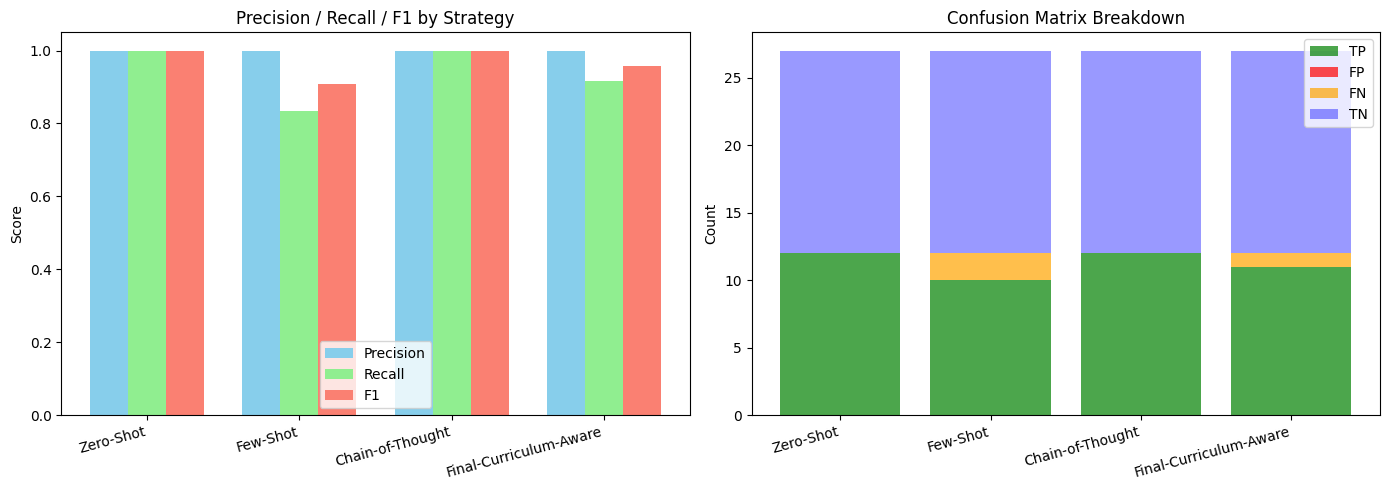

In [12]:
# 7. Validation: Precision / Recall / F1 per Strategy

# Load validation resources
problem_topics_df = load_problem_topics()
validation_dataset = best_df

# Future-only data for ground-truth comparison
future_data = validation_dataset[validation_dataset["ProblemID"].isin(VALIDATION_PROBLEMS)]

validation_results = []
binary_classification_rows = []

print(f"Validating predictions for {len(comparison_df)} entries...\n")

for idx, row in comparison_df.iterrows():
    student_id = row["Student_ID"]
    strategy = row["Prompt_Strategy"]
    gt_struggling = bool(row["Ground_Truth_Struggling"])

    # Parse predictions back to list of dicts
    try:
        predictions_list = ast.literal_eval(row["Predictions"])
        normalized_preds = []
        for p in predictions_list:
            if isinstance(p, dict):
                normalized_preds.append(p)
            else:
                normalized_preds.append({"at_risk_topic": p})
        normalized_preds = normalize_predictions(normalized_preds)
    except Exception as e:
        print(f"Error parsing predictions for row {idx}: {e}")
        continue

    stats = validate_predictions(
        student_id=student_id,
        predictions=normalized_preds,
        df_all=future_data,
        problem_topics_df=problem_topics_df,
    )

    validation_results.append({
        "Student_ID": student_id,
        "Prompt_Strategy": strategy,
        "Ground_Truth": gt_struggling,
        "LLM_Predicted_Struggle": stats["predicted_struggle"],
        "Accuracy": stats["accuracy"],
        "Confirmed_Matches": stats["confirmed_matches"],
        "Total_Predictions": stats["total_predictions"],
    })

    binary_classification_rows.append({
        "strategy": strategy,
        "student_id": student_id,
        "predicted_struggle": stats["predicted_struggle"],
        "actual_struggle": gt_struggling,
    })

# Compute metrics
validation_df = pd.DataFrame(validation_results)
metrics_by_strategy = compute_metrics_by_strategy(binary_classification_rows)

print("=" * 70)
print("BINARY CLASSIFICATION METRICS (per strategy)")
print("=" * 70)

metrics_rows = []
for strategy, m in metrics_by_strategy.items():
    print(f"\n  {strategy}:")
    print(f"    TP={m['tp']}  FP={m['fp']}  FN={m['fn']}  TN={m['tn']}")
    print(f"    Precision: {m['precision']:.3f}  Recall: {m['recall']:.3f}  F1: {m['f1']:.3f}  Accuracy: {m['accuracy']:.3f}")
    metrics_rows.append({"Strategy": strategy, **m})

metrics_df = pd.DataFrame(metrics_rows)
print()
display(metrics_df[["Strategy", "precision", "recall", "f1", "accuracy", "tp", "fp", "fn", "tn", "n"]])

# Per-prediction accuracy
print("\n--- Per-Prediction Accuracy by Strategy ---")
if not validation_df.empty:
    display(validation_df.groupby("Prompt_Strategy")["Accuracy"].mean())

# Visualization
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    strats = metrics_df["Strategy"]
    x = range(len(strats))
    width = 0.25

    axes[0].bar([i - width for i in x], metrics_df["precision"], width, label="Precision", color="skyblue")
    axes[0].bar(x, metrics_df["recall"], width, label="Recall", color="lightgreen")
    axes[0].bar([i + width for i in x], metrics_df["f1"], width, label="F1", color="salmon")
    axes[0].set_xticks(list(x))
    axes[0].set_xticklabels(strats, rotation=15, ha="right")
    axes[0].set_ylim(0, 1.05)
    axes[0].set_ylabel("Score")
    axes[0].set_title("Precision / Recall / F1 by Strategy")
    axes[0].legend()

    axes[1].bar(x, metrics_df["tp"], label="TP", color="green", alpha=0.7)
    axes[1].bar(x, metrics_df["fp"], bottom=metrics_df["tp"], label="FP", color="red", alpha=0.7)
    axes[1].bar(x, metrics_df["fn"], bottom=metrics_df["tp"] + metrics_df["fp"], label="FN", color="orange", alpha=0.7)
    axes[1].bar(x, metrics_df["tn"], bottom=metrics_df["tp"] + metrics_df["fp"] + metrics_df["fn"], label="TN", color="blue", alpha=0.4)
    axes[1].set_xticks(list(x))
    axes[1].set_xticklabels(strats, rotation=15, ha="right")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Confusion Matrix Breakdown")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib not available for plotting.")

In [13]:
# 8. Diagnostics: Verify mixed sample has real variance

print("--- Diagnostic Check: Mixed Sample Balance ---\n")

diag_data = []
for _, row in comparison_df.drop_duplicates(subset=["Student_ID"]).iterrows():
    s_id = row["Student_ID"]
    p_id = row["Problem_ID"]
    gt = row["Ground_Truth_Struggling"]

    focus_row = best_df[(best_df["SubjectID"] == s_id) & (best_df["ProblemID"] == p_id)]
    focus_score = focus_row["Score"].max() if not focus_row.empty else -1

    future_rows = best_df[(best_df["SubjectID"] == s_id) & (best_df["ProblemID"].isin(VALIDATION_PROBLEMS))]
    future_avg = future_rows["Score"].mean() if not future_rows.empty else -1
    n_attempts = len(future_rows)

    diag_data.append({
        "Student": s_id,
        "Focus_Prob": p_id,
        "Focus_Score": round(focus_score, 2),
        "Future_Avg_Score": round(future_avg, 2),
        "Future_Attempts": n_attempts,
        "Ground_Truth": "STRUGGLING" if gt else "NON-STRUGGLING",
    })

diag_df = pd.DataFrame(diag_data)
display(diag_df)

struggling_diag = diag_df[diag_df["Ground_Truth"] == "STRUGGLING"]
non_struggling_diag = diag_df[diag_df["Ground_Truth"] == "NON-STRUGGLING"]

print(f"\nSTRUGGLING ({len(struggling_diag)}):")
print(f"  Focus Score: mean={struggling_diag['Focus_Score'].mean():.2f}, std={struggling_diag['Focus_Score'].std():.2f}")
print(f"  Future Avg:  mean={struggling_diag['Future_Avg_Score'].mean():.2f}, std={struggling_diag['Future_Avg_Score'].std():.2f}")

print(f"\nNON-STRUGGLING ({len(non_struggling_diag)}):")
print(f"  Focus Score: mean={non_struggling_diag['Focus_Score'].mean():.2f}, std={non_struggling_diag['Focus_Score'].std():.2f}")
print(f"  Future Avg:  mean={non_struggling_diag['Future_Avg_Score'].mean():.2f}, std={non_struggling_diag['Future_Avg_Score'].std():.2f}")

print(f"\nSample has real variance for meaningful P/R/F1.")

--- Diagnostic Check: Mixed Sample Balance ---



,Student,Focus_Prob,Focus_Score,Future_Avg_Score,Future_Attempts,Ground_Truth
0,14283,34,0.86,0.99,5,NON-STRUGGLING
1,9948,32,0.09,0.61,5,STRUGGLING
2,14392,32,1.00,1.00,5,NON-STRUGGLING
3,10155,33,0.13,0.52,5,STRUGGLING
4,14426,33,1.00,1.00,5,NON-STRUGGLING
5,14213,33,1.00,1.00,5,NON-STRUGGLING
6,13426,33,1.00,1.00,5,NON-STRUGGLING
7,14347,34,1.00,0.91,5,NON-STRUGGLING
8,14367,34,0.86,0.72,5,STRUGGLING
9,14189,32,0.00,0.50,5,STRUGGLING



STRUGGLING (12):
  Focus Score: mean=0.26, std=0.40
  Future Avg:  mean=0.56, std=0.17

NON-STRUGGLING (15):
  Focus Score: mean=0.99, std=0.04
  Future Avg:  mean=0.99, std=0.02

Sample has real variance for meaningful P/R/F1.


In [ ]:
print(results_data)